# 문제 3. 표준오차

**📘 문제**

- 앞선 실습에서 우리는 **표본 크기(n)가 커질수록 표본 평균들의 분포가 더 좁아진다**는 것을 확인했습니다.
- 이처럼 표본 평균들이 얼마나 흩어져 있는지(분포의 퍼진 정도)를 나타내는 값을 **표준오차(Standard Error, SE)**라고 부릅니다.
- 표준오차는 **표본 평균들의 표준편차**와 같은 의미이며, 이는 우리가 뽑은 표본 평균이 실제 모평균과 평균적으로 얼마나 떨어져 있을지를 나타내는 **'예상 오차의 크기'**입니다.

- 통계학적으로 이 표준오차는 **`SE = σ / √n`** (모집단 표준편차 / 표본 크기의 제곱근) 이라는 공식으로 계산할 수 있습니다.
- 이 공식은 **표본 크기(n)가 커질수록 표준오차(SE)가 작아진다**는 것을 명확히 보여줍니다.

- 이번 실습에서는 여러 크기의 표본을 뽑아, 시뮬레이션을 통해 얻은 **표본 평균들의 표준편차(실험값)**가 공식으로 계산한 **표준오차(이론값)**와 얼마나 일치하는지 직접 확인해봅니다.

In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# OS별 한글 폰트 자동 설정 (macOS: AppleGothic, Windows: Malgun Gothic, Colab/Linux: NanumGothic)
system = platform.system()
if system == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지


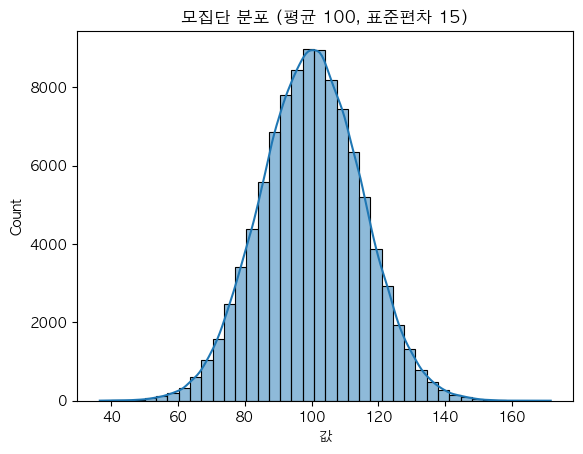

In [3]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 여러 크기의 표본(10, 30, 100, 500)을 각각 1000번 뽑고, 그 평균들을 구한 뒤, **표본 평균들의 표준편차(=실험적 표준오차)**를 계산해봅시다.

- 이 결과를 이론적인 표준오차 공식과 비교하는 표를 만들고, 시각화해봅시다.

In [4]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.
def get_sample_means(n, repeat=1000):
    np.random.seed(2025)
    return [np.random.choice(population, size=n, replace=False).mean() for i in range(repeat)]

sample_sizes = [10, 30, 100, 500]
sample_means_dict = {n: get_sample_means(n) for n in sample_sizes}

experimental_se = [np.std(sample_means_dict[n]) for n in sample_sizes]

df_se = pd.DataFrame({
    "표본크기": sample_sizes,
    "실험적_표준오차": experimental_se
})
df_se


# 여기에 코드를 작성해주세요.

,표본크기,실험적_표준오차
0,10,4.558660
1,30,2.689713
2,100,1.477130
3,500,0.661012


In [5]:
# [문제 3] Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

# 여기에 코드를 작성해주세요.
theoretical_se = [population.std() / np.sqrt(n) for n in sample_sizes]

df_se["이론적_표준오차"] = theoretical_se
df_se


,표본크기,실험적_표준오차,이론적_표준오차
0,10,4.558660,4.753921
1,30,2.689713,2.744677
2,100,1.477130,1.503322
3,500,0.661012,0.672306


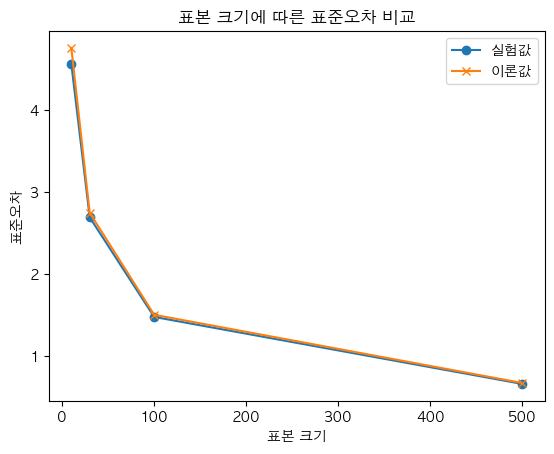

In [6]:
# [문제 3] Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

# 여기에 코드를 작성해주세요.
plt.plot(df_se["표본크기"], df_se["실험적_표준오차"], marker='o', label='실험값')
plt.plot(df_se["표본크기"], df_se["이론적_표준오차"], marker='x', label='이론값')
plt.title("표본 크기에 따른 표준오차 비교")
plt.xlabel("표본 크기")
plt.ylabel("표준오차")
plt.legend()
plt.show()


**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?

- 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?

- 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?

- 왜 표본 크기가 커질수록 표준오차는 작아질까요?

### [문제 3] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- 표본 크기가 작을수록 표본오차가 크기때문에 표본 평균의 분포는 넓게 퍼져있다.
- 표본 크기가 커질수록 평균 분포는 좁게 변한다.
- 실험값과 이론값은 거의 일치한다.
- 표준오차 공식 `SE = σ / √n`에 따르면 n이 표본 크기인데 n이 커질수록 √n도 커지고, σ를 더 큰 수로 나누게 되니까 SE는 작아지게 된다.
